In [1]:
import numpy as np
import mmcfilters
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv

import mtviz as viz
import mmcfilters



In [2]:
imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/cable.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/images/peppers_gray.tif", cv.IMREAD_GRAYSCALE)

(num_rows, num_cols) = imgInput.shape



In [4]:
AT= mmcfilters.Attribute.Type
tree = mmcfilters.WeightedMorphologicalTree.createTreeOfShapes(imgInput, interpolation=mmcfilters.ToSInterpolation.SelfDual)
mmcfilters.Attribute.computeAttributes(tree, [AT.AREA, AT.VOLUME, AT.BOX_HEIGHT])

({'AREA': 0, 'VOLUME': 1, 'BOX_HEIGHT': 2},
 array([[2.5000000e+05, 3.2991866e+07, 5.0000000e+02],
        [3.3830000e+04, 3.7804140e+06, 2.0000000e+02],
        [1.1156400e+05, 1.0283698e+07, 4.7800000e+02],
        [8.9290000e+03, 6.4288800e+05, 1.1400000e+02],
        [1.5485000e+04, 8.3619000e+05, 1.8300000e+02],
        [2.4413000e+04, 2.4757900e+06, 2.8100000e+02],
        [1.6137000e+04, 2.2688160e+06, 1.7500000e+02],
        [3.0180000e+03, 1.5665700e+05, 6.8000000e+01],
        [4.2100000e+02, 1.6419000e+04, 2.3000000e+01],
        [6.8210000e+03, 2.5919800e+05, 9.7000000e+01]], dtype=float32))

In [6]:
import pandas as pd
ok = True
selected_attributes = [
    mmcfilters.Attribute.Type.AREA,
    mmcfilters.Attribute.Type.INERTIA,
    mmcfilters.Attribute.Type.BOX_HEIGHT,
]
trainset = ["../dat/imgTeste.png", "../dat/imgObjetos.png", "../dat/cable.png"]
for i in range(len(trainset)):
    img = cv.imread(trainset[i], cv.IMREAD_GRAYSCALE)
    (img_rows, img_cols) = img.shape
    tree = mmcfilters.WeightedMorphologicalTree.createTreeOfShapes(imgInput, interpolation=mmcfilters.ToSInterpolation.SelfDual)
    features, attrs = mmcfilters.Attribute.computeAttributes(tree, selected_attributes)

    df2 = pd.DataFrame(attrs, columns=list(features.keys()))
    if len(df2[df2.isna().any(axis=1)]) > 0:
        print(i, df2[df2.isna().any(axis=1)])
        ok = False
if ok:
    print("Attributes verified, no NaN values found in the selected subset.")

Attributes verified, no NaN values found in the selected subset.


In [7]:
maxtree = mmcfilters.WeightedMorphologicalTree.createMaxTree(imgInput, 1.5)
mintree = mmcfilters.WeightedMorphologicalTree.createMinTree(imgInput, 1.5)
tos = mmcfilters.WeightedMorphologicalTree.createTreeOfShapes(imgInput, interpolation=mmcfilters.ToSInterpolation.SelfDual)
tos4c8c = mmcfilters.WeightedMorphologicalTree.createTreeOfShapes(imgInput, interpolation=mmcfilters.ToSInterpolation.Min4cMax8c)

filterMaxtree = mmcfilters.AttributeFilters(maxtree)
filterMintree = mmcfilters.AttributeFilters(mintree)
filterToS = mmcfilters.AttributeFilters(tos)
filterToS4c8c = mmcfilters.AttributeFilters(tos4c8c)

selected_attributes = [
    mmcfilters.Attribute.Type.AREA,
    mmcfilters.Attribute.Type.INERTIA,
    mmcfilters.Attribute.Type.BOX_HEIGHT,
]
dic, attrs_maxtree = mmcfilters.Attribute.computeAttributes(maxtree, selected_attributes)
dic, attrs_mintree = mmcfilters.Attribute.computeAttributes(mintree, selected_attributes)
dic, attrs_tos = mmcfilters.Attribute.computeAttributes(tos, selected_attributes)
dic, attrs_tos4c8c = mmcfilters.Attribute.computeAttributes(tos4c8c, selected_attributes)
dic

{'AREA': 0, 'BOX_HEIGHT': 1, 'INERTIA': 2}

In [8]:
pt = viz.PrintTree(lambda n: tos.getChildren(n), lambda n: f"id:{n}: altitude: {tos.getAltitude(n)}")
pt(tos.getRoot())

                             id:0: altitude: 203
         ┌────────────────────────────┴┬────────────────────────────┐
id:1: altitude: 126            id:2: altitude: 78           id:4: altitude: 54
         |                   ┌─────────┴─────────┐                            
 id:3: altitude: 72 id:5: altitude: 126 id:6: altitude: 161                   
                             |                   |                            
                     id:9: altitude: 38  id:7: altitude: 54                   
                                                 |                            
                                         id:8: altitude: 39


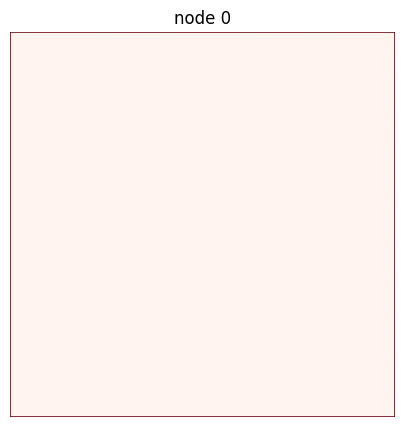

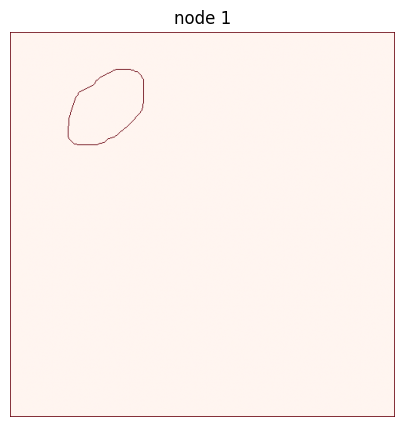

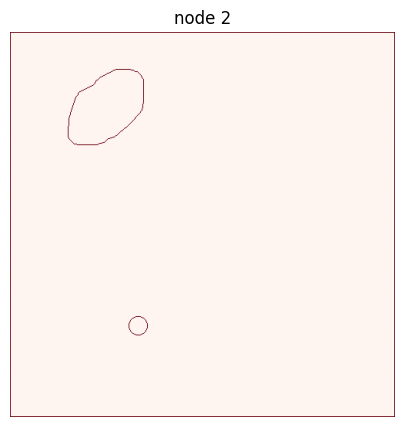

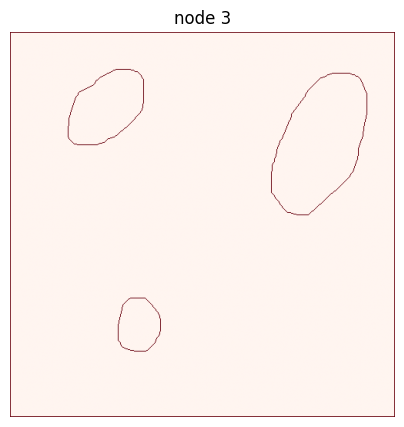

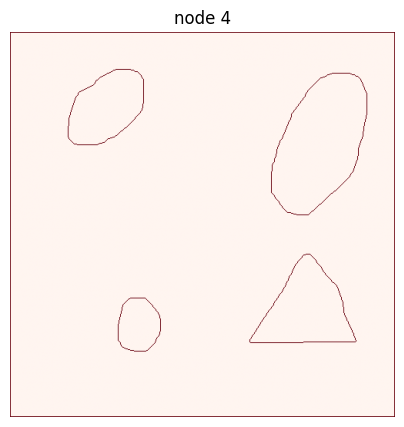

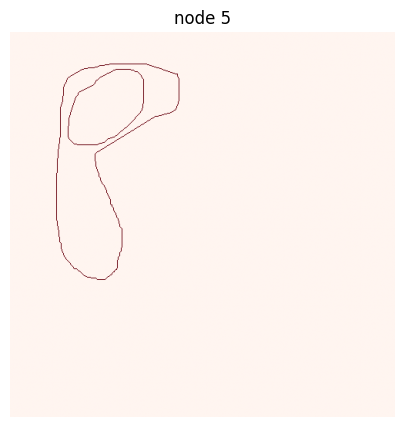

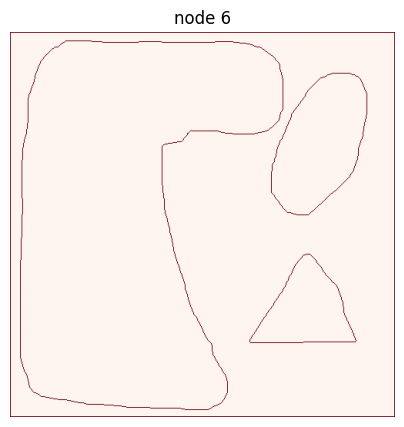

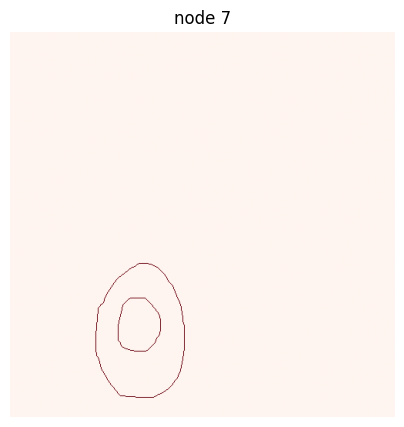

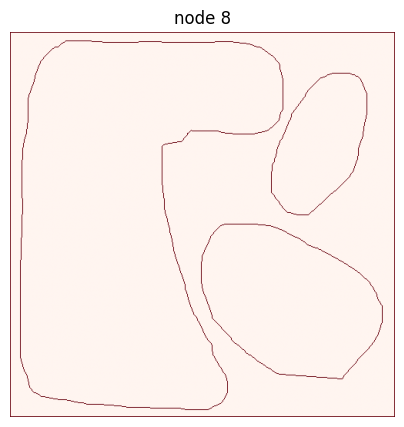

In [9]:
def plotCountors(pixels, node_id, num_rows, num_cols):
    contour_img = np.zeros((num_rows, num_cols), dtype=np.uint8)

    for p in pixels:
        row = p // num_cols
        col = p % num_cols
        contour_img[row, col] = 255

    plt.figure(figsize=(5, 5))
    plt.imshow(contour_img, cmap='Reds')
    plt.title(f"node {node_id}")
    plt.axis('off')
    plt.show()

mtContours = mmcfilters.ContourComputation.extraction(maxtree)
area_col = dic['AREA']
for nodeId, contour in mtContours.contoursByNode():
    if attrs_maxtree[nodeId, area_col] > 100:
        plotCountors(contour, nodeId, num_rows, num_cols)

Text(0.5, 1.0, 'attribute filter (tos)')

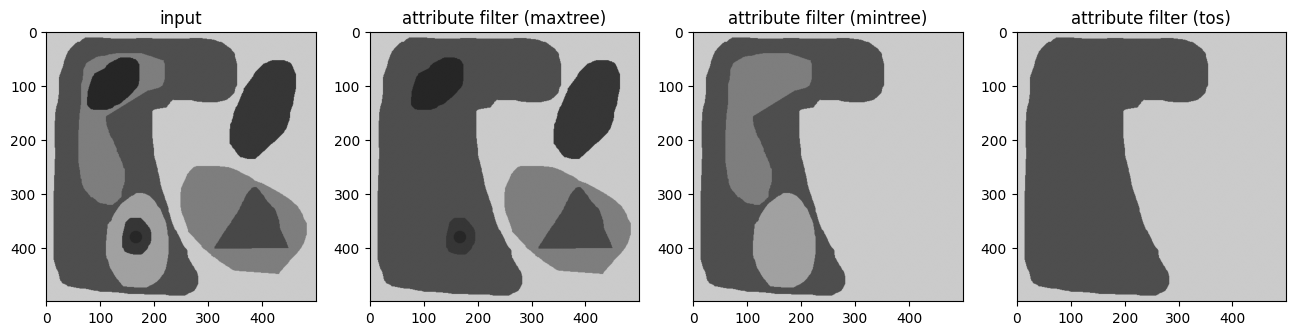

In [10]:
area_col = dic['AREA']
threshold = (num_rows*num_cols) *0.25

att_maxtree = attrs_maxtree[:, area_col]
att_mintree = attrs_mintree[:, area_col]
att_tos = attrs_tos[:, area_col]

imgFilteredMaxtree = filterMaxtree.filteringDirectRule(att_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringDirectRule(att_mintree > threshold)
imgFilteredToS = filterToS.filteringDirectRule(att_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

Text(0.5, 1.0, 'attribute filter (tos)')

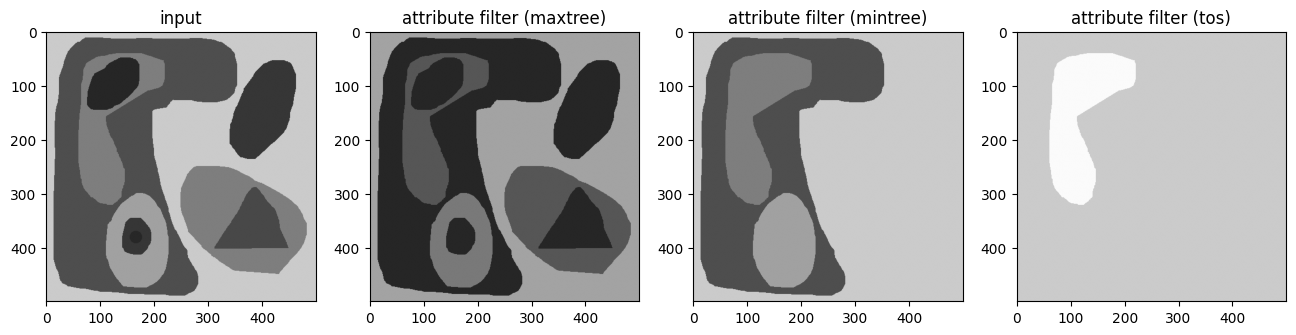

In [11]:
inertia_col = dic['INERTIA']
threshold = 0.2

att_maxtree = attrs_maxtree[:, inertia_col]
att_mintree = attrs_mintree[:, inertia_col]
att_tos = attrs_tos[:, inertia_col]

imgFilteredMaxtree = filterMaxtree.filteringSubtractiveRule(att_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringSubtractiveRule(att_mintree > threshold)
imgFilteredToS = filterToS.filteringSubtractiveRule(att_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')